In [1]:
import sys as _sys
from pathlib import Path as _Path
try:
    _sys.path.insert(0, str(_Path(__vsc_ipynb_file__).parent.parent))
except NameError:
    pass  # Not in VS Code; rely on pip install -e .

import os
from scripts.utils import setup_notebook, OKABE_ITO_CYCLE

PROJECT_ROOT, np, pd, plt, Path = setup_notebook()

from scripts.data_loader import AHE_hysteresis
from scripts.ahe_collection import AHE_Collection

color_values = OKABE_ITO_CYCLE
Save = True

RAW_DATA_DIR = PROJECT_ROOT / "data" / "T vs EB" / "P2500 mTPF"
PLOTS_DIR    = PROJECT_ROOT / "figures"
RESULTS_DIR  = PROJECT_ROOT / "results"
PLOTS_DIR.mkdir(exist_ok=True)

folder = RAW_DATA_DIR
print(f"Raw data folder: {RAW_DATA_DIR}")
print(f"Figures folder: {PLOTS_DIR}")

[OK] Autoreload enabled
[OK] Project root: c:\Users\sadit\OneDrive - JGU\Projects\EB-in FGT-CrSBr
[OK] Matplotlib configured (Okabe-Ito palette, publication style)
Setup complete!
Raw data folder: c:\Users\sadit\OneDrive - JGU\Projects\EB-in FGT-CrSBr\data\T vs EB\P2500 mTPF
Figures folder: c:\Users\sadit\OneDrive - JGU\Projects\EB-in FGT-CrSBr\figures


In [2]:
EBvT_PF_P = AHE_Collection(RAW_DATA_DIR)

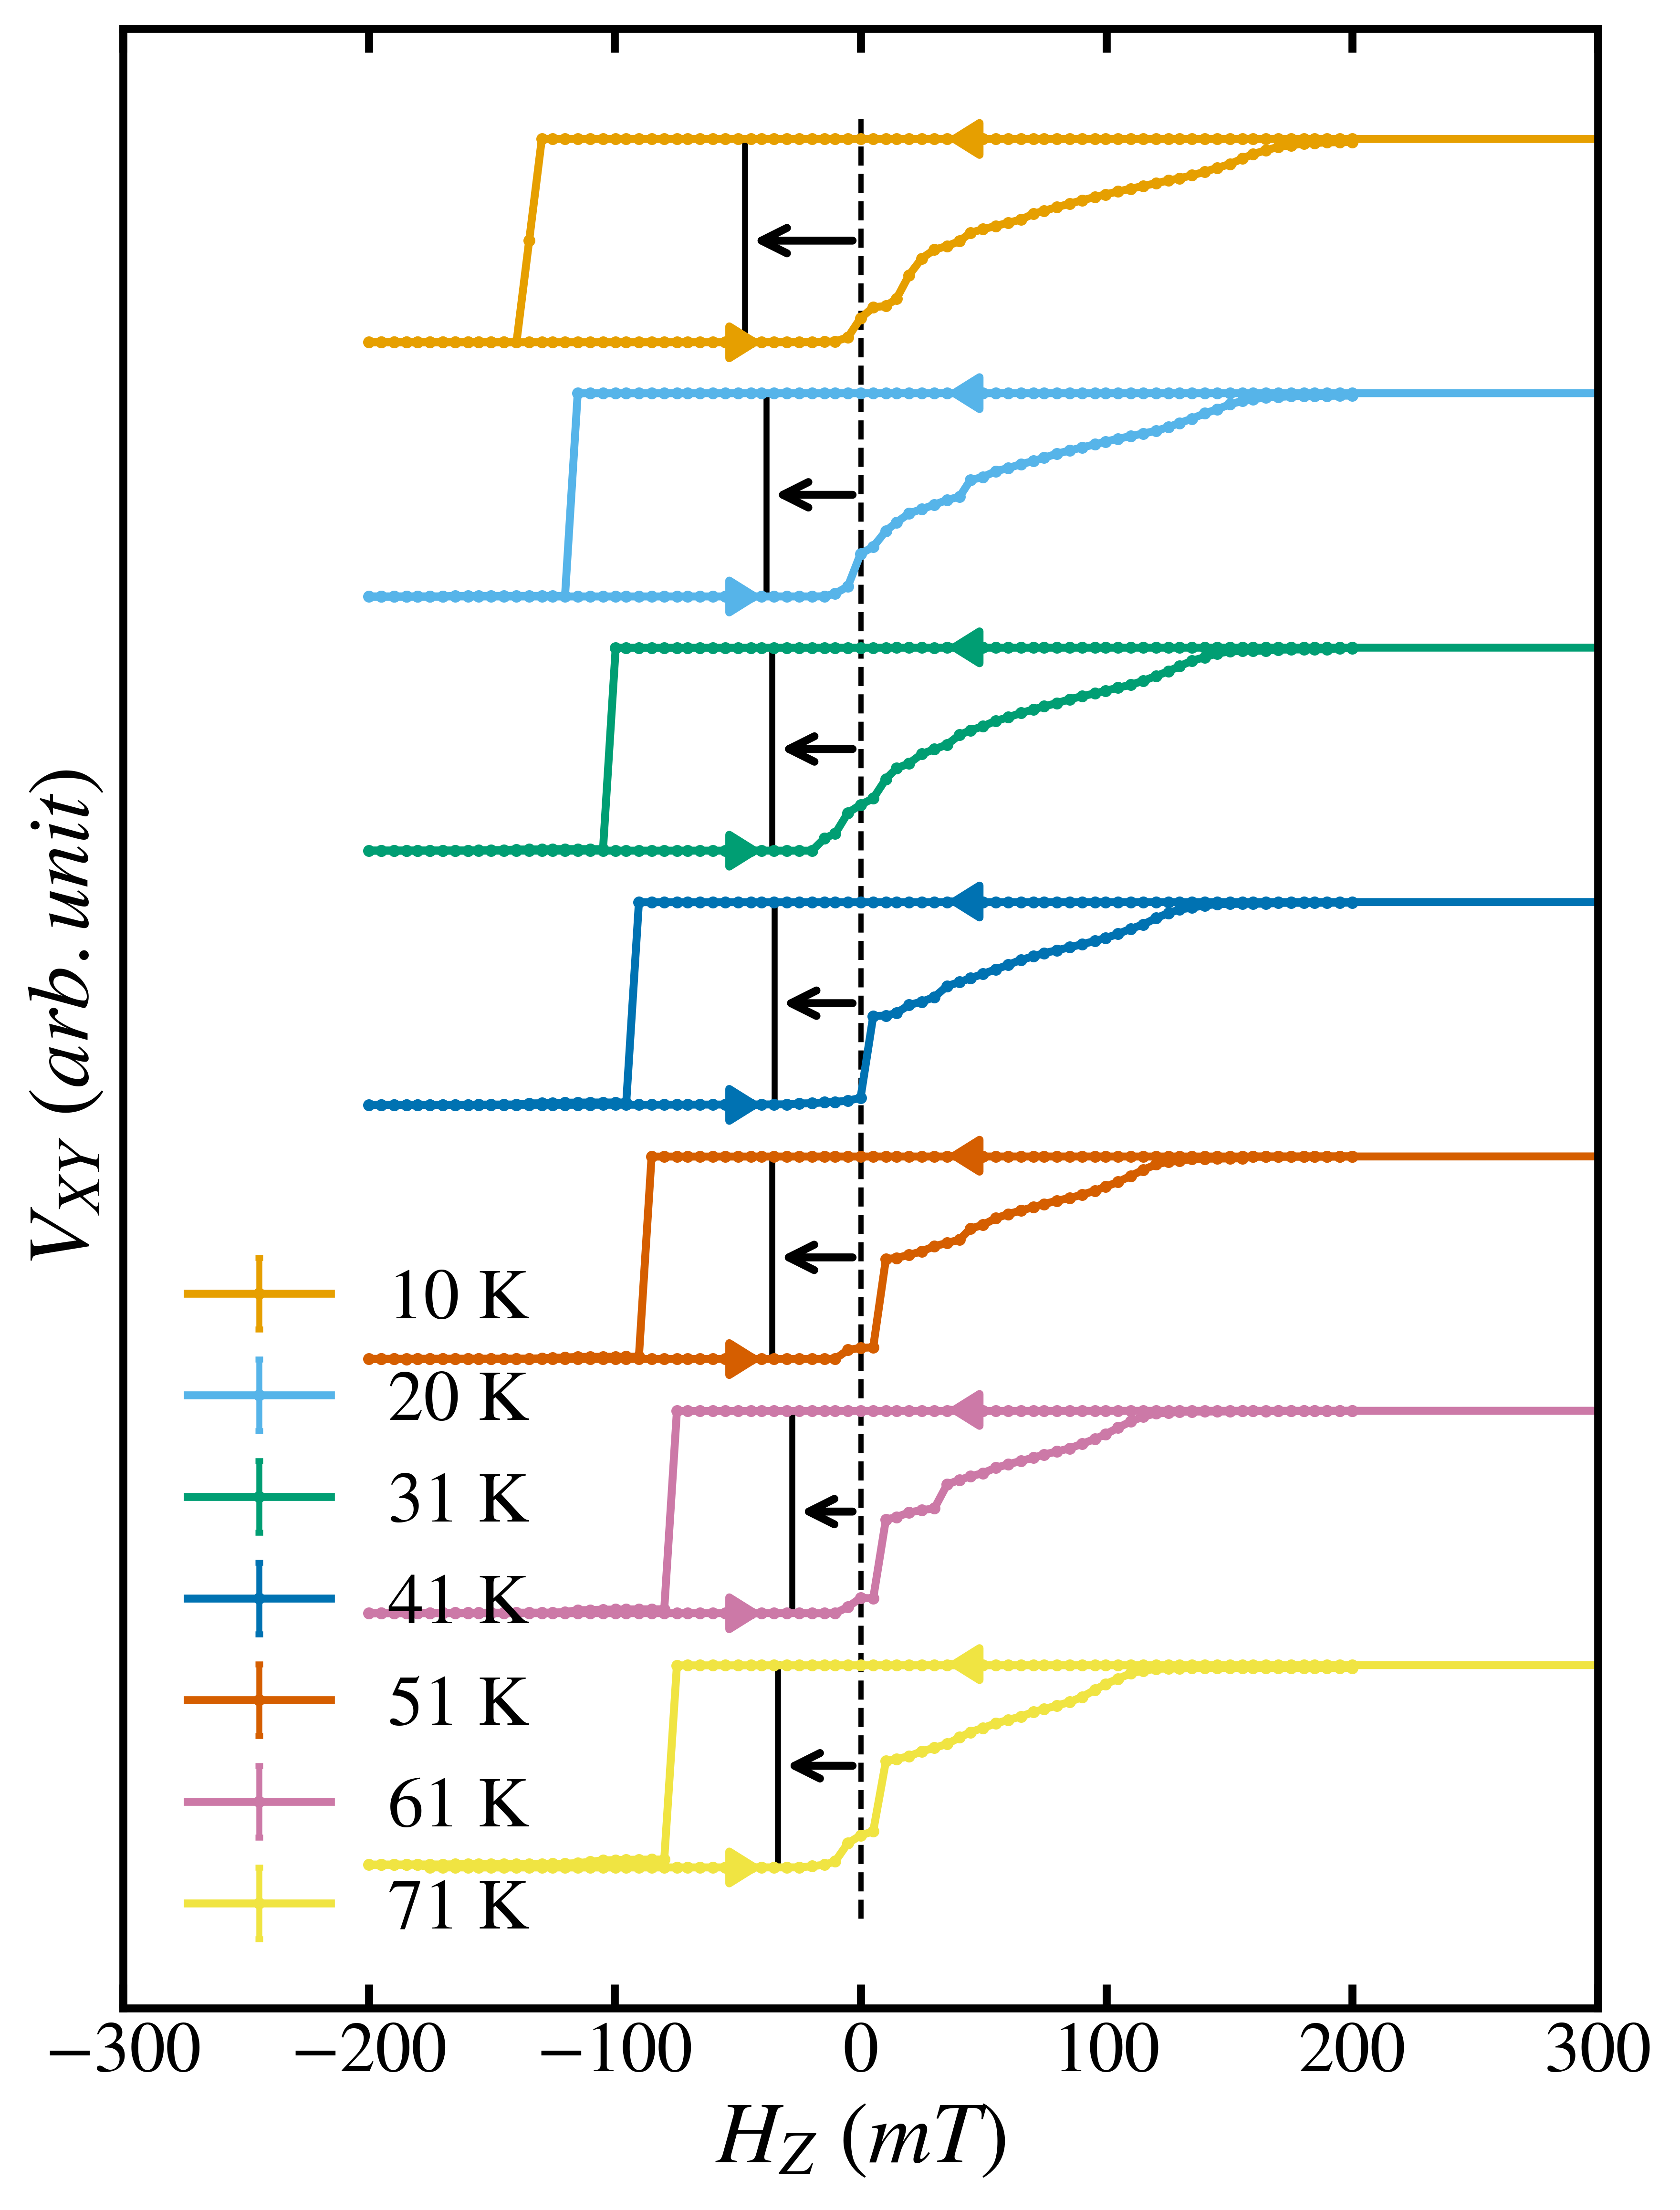

In [3]:
fig, ax = plt.subplots(figsize=(6, 8), dpi=600)

for i, (key, obj) in enumerate(EBvT_PF_P.measurements.items()):
    vspacing = 2.5
    n = 7
    if i<n:
        color = color_values[i % len(color_values)]
        ax.errorbar(obj.field, obj.vxy_norm - vspacing*i, obj.vxy_err/obj.vahe, fmt='-o',
        color=color,
        label=key,
        capsize=1, markersize = 1.5,
        elinewidth=1.5,
        markeredgewidth=1.5)

        ax.plot(
        [obj.heb, obj.heb],   # vertical line at coercivity
        np.array([1, -1]) - i * vspacing,
        color='k',
        linestyle='-',
        linewidth=1.5
    )

        arrow_loop_down = 1 - i * vspacing  # Y-position for the arrow (slightly above center line)

        ax.annotate(
            '',  # No text
            xy=(35, arrow_loop_down),   # arrow head
            xytext=(40, arrow_loop_down),      # arrow tail (starting point)
            arrowprops=dict(
                arrowstyle='-|>,head_width=0.25',
                color=color,
                linewidth=2
            )
        )

        arrow_loop_up = -1 - i * vspacing  # Y-position for the arrow (slightly above center line)

        ax.annotate(
            '',  # No text
            xy=(-40, arrow_loop_up),   # arrow head
            xytext=(-45, arrow_loop_up),      # arrow tail (starting point)
            arrowprops=dict(
                arrowstyle='-|>,head_width=0.25',
                color=color,
                linewidth=2
            )
        )

        arrow_y = 0 - i * vspacing  # Y-position for the arrow (slightly above center line)

        ax.annotate(
            '',  # No text
            xy=(obj.heb, arrow_y),   # arrow head
            xytext=(0, arrow_y),      # arrow tail (starting point)
            arrowprops=dict(
                arrowstyle='->',
                color='k',
                linewidth=2
            )
        )

# --- Vertical zero line ---
ax.plot([0, 0], [1.2, n*-vspacing + 1], color='k', linestyle='--', linewidth=1.3)

ax.set_xlabel("$H_Z$ $(mT)$")
ax.set_ylabel("$V_{XY}$ $(arb. unit)$")
ax.set_yticks([])  # Remove y-axis ticks for clean stacking
ax.legend(loc='lower left',  frameon=False)
plt.tight_layout()
plt.xlim(-300,300)




plt.savefig(os.path.join(PLOTS_DIR,"PFP2500mT_10K to 80K.png"))
plt.show()

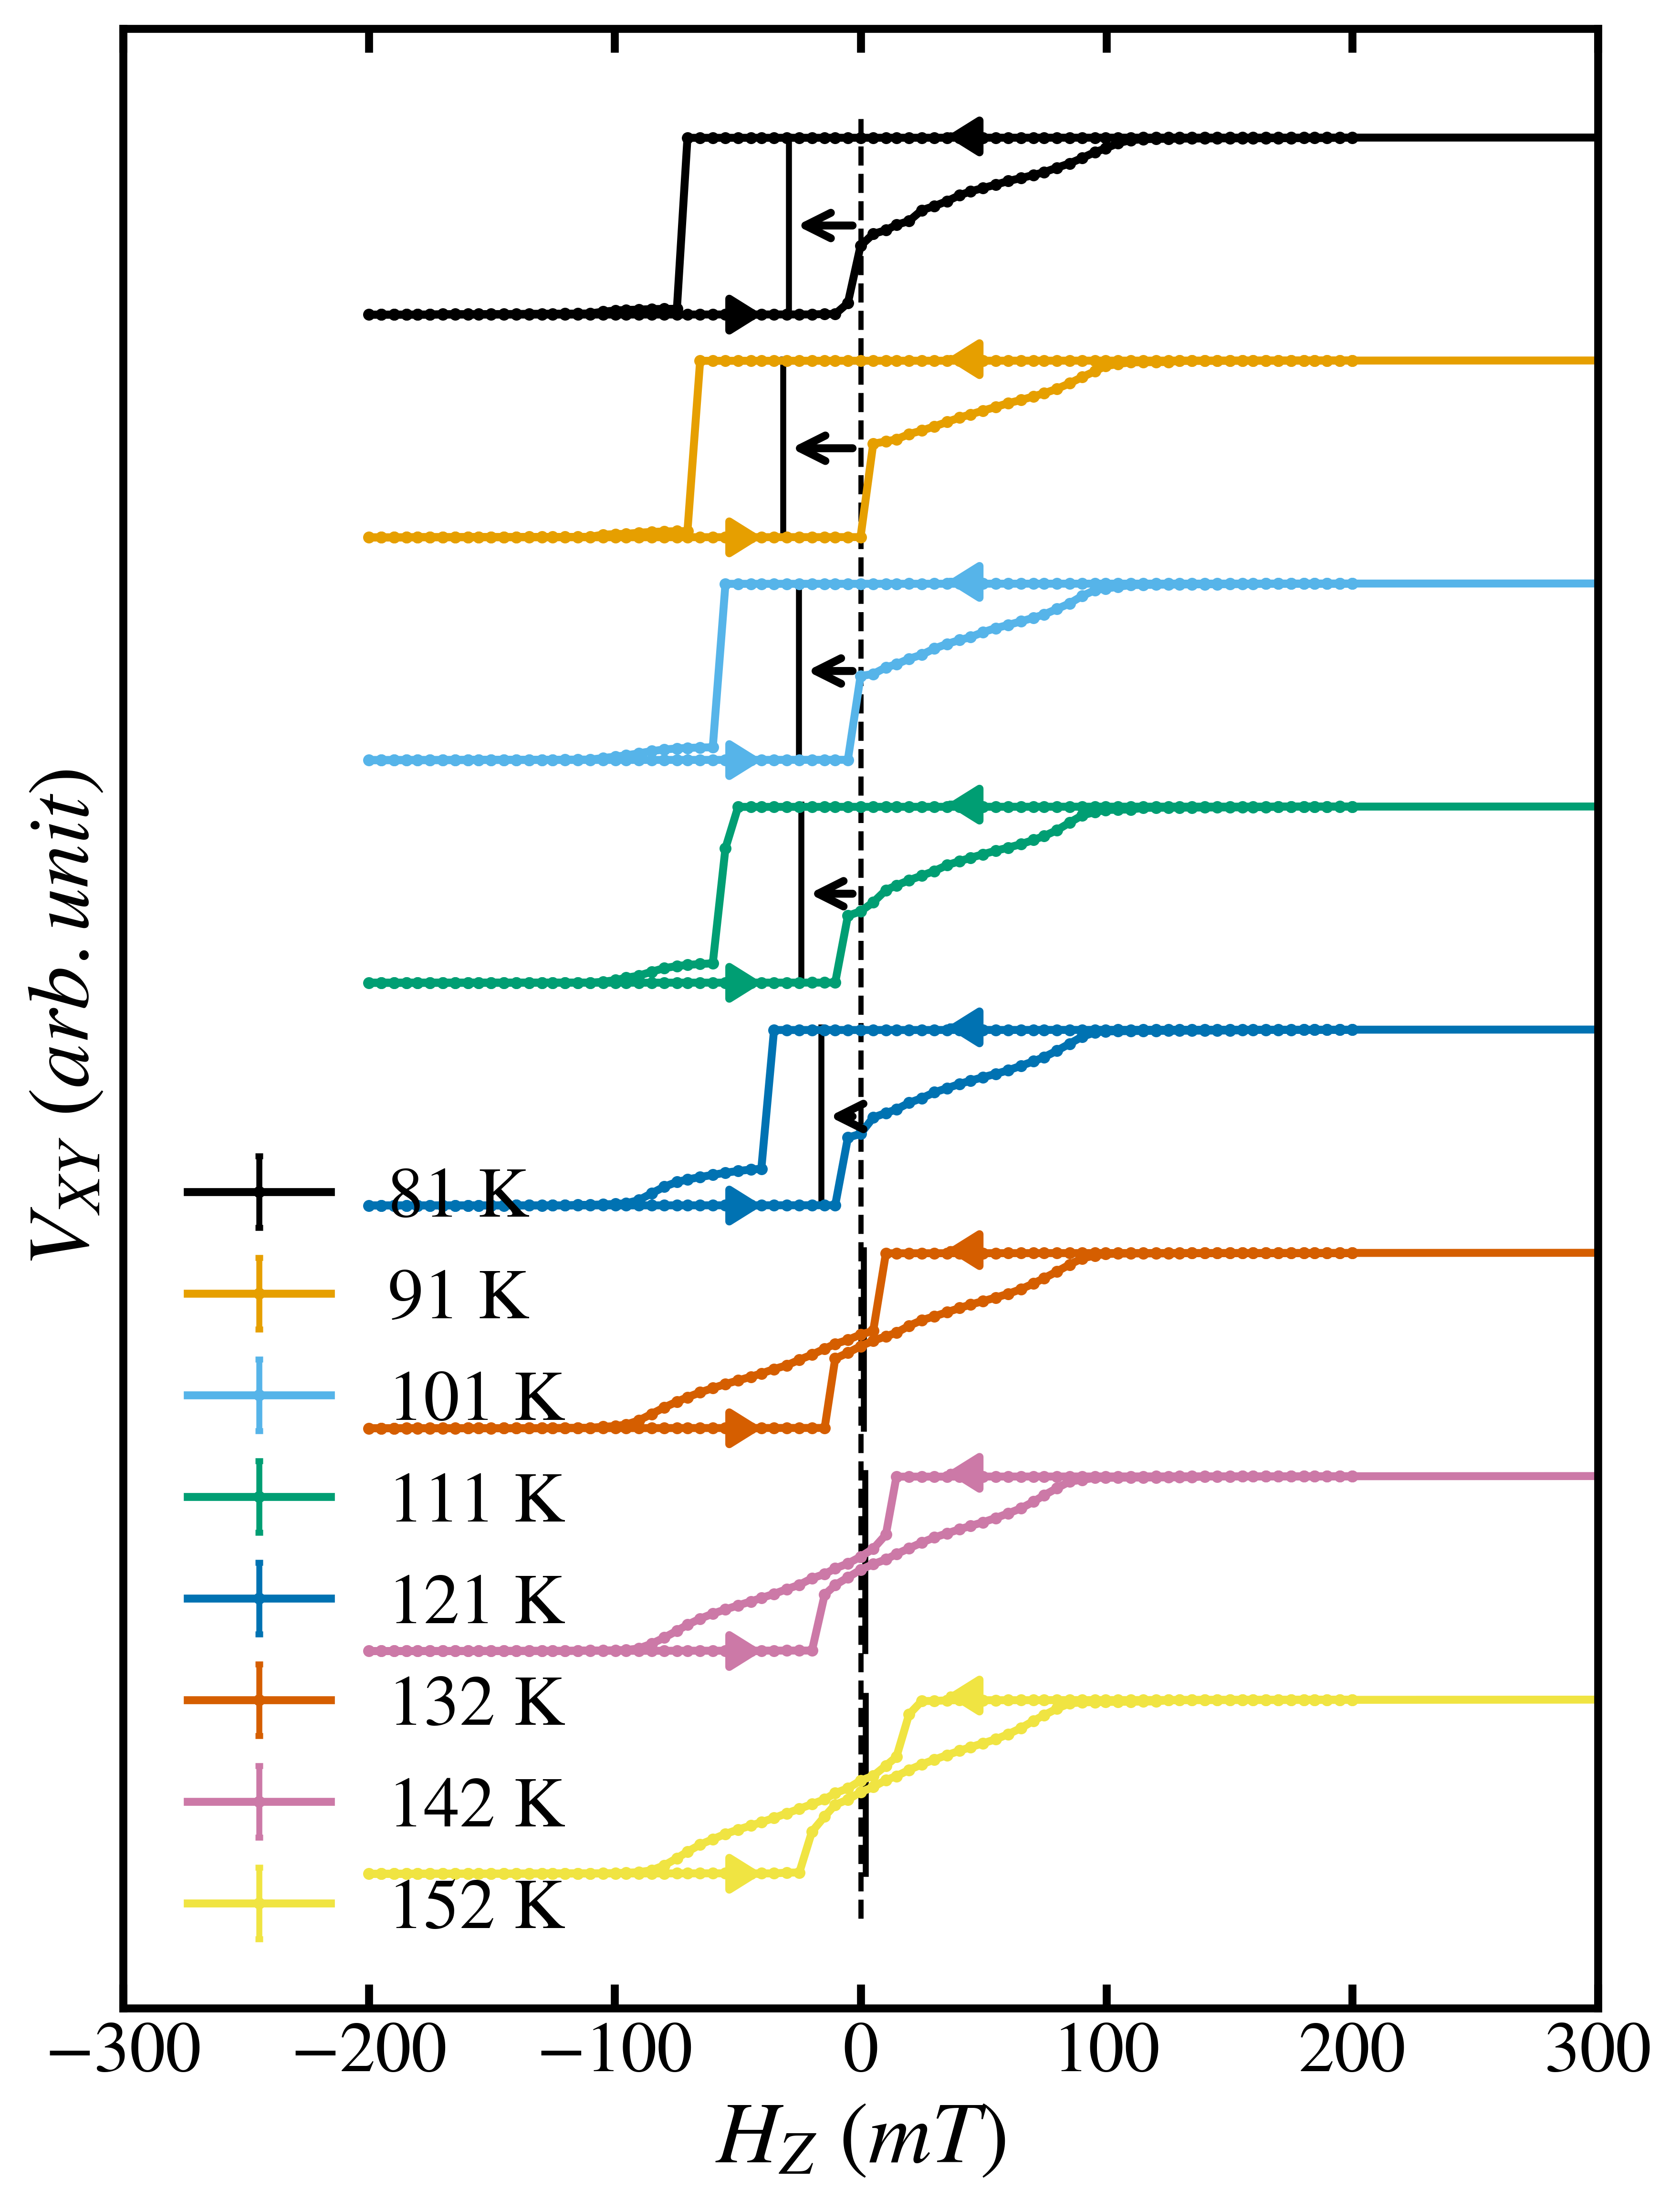

In [4]:
fig, ax = plt.subplots(figsize=(6, 8), dpi=600)

for i, (key, obj) in enumerate(EBvT_PF_P.measurements.items()):
    vspacing = 2.5
    if i>=n:
        color = color_values[i % len(color_values)]
        ax.errorbar(obj.field, obj.vxy_norm - vspacing*i, obj.vxy_err/obj.vahe, fmt='-o',
        color=color,
        label=key,
        capsize=1, markersize = 1.5,
        elinewidth=1.5,
        markeredgewidth=1.5)

        ax.plot(
        [obj.heb, obj.heb],   # vertical line at coercivity
        np.array([1, -1]) - i * vspacing,
        color='k',
        linestyle='-',
        linewidth=1.5
    )

        arrow_loop_down = 1 - i * vspacing  # Y-position for the arrow (slightly above center line)

        ax.annotate(
            '',  # No text
            xy=(35, arrow_loop_down),   # arrow head
            xytext=(40, arrow_loop_down),      # arrow tail (starting point)
            arrowprops=dict(
                arrowstyle='-|>,head_width=0.25',
                color=color,
                linewidth=2
            )
        )

        arrow_loop_up = -1 - i * vspacing  # Y-position for the arrow (slightly above center line)

        ax.annotate(
            '',  # No text
            xy=(-40, arrow_loop_up),   # arrow head
            xytext=(-45, arrow_loop_up),      # arrow tail (starting point)
            arrowprops=dict(
                arrowstyle='-|>,head_width=0.25',
                color=color,
                linewidth=2
            )
        )
        if i < 12:
            arrow_y = 0 - i * vspacing  # Y-position for the arrow (slightly above center line)

            ax.annotate(
                '',  # No text
                xy=(obj.heb, arrow_y),   # arrow head
                xytext=(0, arrow_y),      # arrow tail (starting point)
                arrowprops=dict(
                    arrowstyle='->',
                    color='k',
                    linewidth=2
                )
            )

# --- Vertical zero line ---
ax.plot([0, 0], [1.2 - n*vspacing, 15*-vspacing + 1], color='k', linestyle='--', linewidth=1.3)

ax.set_xlabel("$H_Z$ $(mT)$")
ax.set_ylabel("$V_{XY}$ $(arb. unit)$")
ax.set_yticks([])  # Remove y-axis ticks for clean stacking
ax.legend(loc='lower left',  frameon=False)
plt.tight_layout()
plt.xlim(-300,300)




plt.savefig(os.path.join(PLOTS_DIR,"PFP2500mT_80K to 150K.png"))
plt.show()

In [5]:
savepath = os.path.join(RESULTS_DIR,"PFP2500mT_Tvs_EB.csv")
if EBvT_PF_P.attributes is not None:
    EBvT_PF_P.attributes.to_csv(savepath, index=False)
    print(f"Saved attributes to {savepath}")
else:
    print("No attributes found to save.")

Saved attributes to c:\Users\sadit\OneDrive - JGU\Projects\EB-in FGT-CrSBr\results\PFP2500mT_Tvs_EB.csv
